# A Complete Classification Pipeline

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

In the previous notebook you built your first Pipeline for a regression task. This time you build one for classification, end to end: mixed feature types, missing values imputed <b>inside</b> the pipeline, a tuned <code>LogisticRegression</code>, and an honest final evaluation on a held-back test set.

The dataset is the telecom-churn table you have worked with before, but where earlier work used only its numeric columns and dropped the rows with missing values, the pipeline will handle all of it. You will finish with <b>error analysis</b>: reading the model's worst mistakes as real customers, which is where the ideas for your next improvement could come from.

</div>

---
## Step 1: Load and Fix Types

Two cleaning steps belong before any pipeline, because they are about the meaning of columns, not about learned statistics. `TotalCharges` is stored as text (a few rows contain blank strings), so we convert it to numbers, letting anything unparseable become missing. And `customerID` is an identifier with no predictive meaning, so it goes.

> **Data source:** Telco Customer Churn dataset (IBM sample data, via Kaggle), distributed with this course as `telco_churn.csv`. Download it from the course folder and place it in the same directory as this notebook.

Note what we do **not** do: we do not drop the rows with missing `TotalCharges`. Imputation is a learned statistic (the median comes from somewhere), so it belongs inside the pipeline, fit on training data only.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_SEED = 23

df = pd.read_csv('telco_churn.csv')
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn', 'customerID'])

print(f"Rows: {len(df)}")
print(f"Missing TotalCharges after conversion: {X['TotalCharges'].isna().sum()}")
print(f"Churn rate: {y.mean():.3f}")

Rows: 7043
Missing TotalCharges after conversion: 11
Churn rate: 0.265


---
## Step 2: A Three-Way Split

We are going to tune the regularization strength `C`, and tuning needs somewhere to happen. So this notebook uses the full three-way discipline: a training set to fit on, a validation set to compare settings on, and a test set that stays untouched until the very end. Stratified splits keep the churn rate consistent everywhere.

We also need to tell the pipeline which columns are which. Building the lists from the column types scales to any table and will serve you well on new datasets.

In [4]:
# 60/20/20: first carve off the test set, then split the rest into train and validation
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_SEED, stratify=y_trainval)

print(f"Train: {len(X_train)}   Validation: {len(X_val)}   Test: {len(X_test)}")
print(f"Churn rate: train {y_train.mean():.3f}, val {y_val.mean():.3f}, test {y_test.mean():.3f}")

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f"\nNumeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Train: 4225   Validation: 1409   Test: 1409
Churn rate: train 0.265, val 0.265, test 0.265

Numeric (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


> **Note:** Always eyeball the generated lists before trusting them. Here they are right: `SeniorCitizen` is already a 0/1 number, and the other 15 columns are genuine categories. Fifteen categorical columns encoded by hand, with fit-on-train discipline repeated for each, would be slow and error-prone. Declared once in a ColumnTransformer, they take three lines.

---
## Step 3: Preprocessing with a Branch Pipeline

One new trick. A branch of a `ColumnTransformer` can itself be a `Pipeline`. The numeric columns need two steps in a fixed order: impute missing values first, then scale (a scaler cannot digest missing values). So the numeric branch is a tiny two-step pipeline, nested inside the big one.

We wrap the whole construction in a small function, because we are about to build several variants of it, and a function guarantees every variant differs only in what we deliberately change.

In [5]:
def make_churn_pipeline(num_features, cat_features, C=1.0):
    """Preprocessing + LogisticRegression for the churn task."""
    numeric_branch = Pipeline(steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    preprocess = ColumnTransformer(transformers=[
        ('num', numeric_branch, num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features),
    ])
    return Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_SEED)),
    ])


def evaluate(pipe, X_eval, y_eval):
    """Return the four core classification metrics as a dict."""
    pred = pipe.predict(X_eval)
    return {
        'accuracy': accuracy_score(y_eval, pred),
        'precision': precision_score(y_eval, pred),
        'recall': recall_score(y_eval, pred),
        'f1': f1_score(y_eval, pred),
    }

---
## Step 4: Do the Categorical Columns Help?

Earlier work on this dataset used only the four numeric columns. Now that encoding costs nothing, the natural first experiment is: how much do the 15 categorical columns actually add? We compare a numeric-only pipeline against the full one, with the always-predict-majority baseline for context.

In [6]:
majority_acc = max(1 - y_val.mean(), y_val.mean())
print(f"Majority-class baseline accuracy: {majority_acc:.3f}\n")

numeric_pipe = make_churn_pipeline(num_cols, []).fit(X_train, y_train)
full_pipe = make_churn_pipeline(num_cols, cat_cols).fit(X_train, y_train)

print(f"{'pipeline':<14} {'accuracy':>9} {'precision':>10} {'recall':>7} {'F1':>6}")
for name, pipe in [('numeric only', numeric_pipe), ('all features', full_pipe)]:
    m = evaluate(pipe, X_val, y_val)
    print(f"{name:<14} {m['accuracy']:>9.3f} {m['precision']:>10.3f} {m['recall']:>7.3f} {m['f1']:>6.3f}")

n_features = full_pipe.named_steps['preprocess'].get_feature_names_out().shape[0]
print(f"\nFull pipeline feature count after encoding: {n_features}")

Majority-class baseline accuracy: 0.735

pipeline        accuracy  precision  recall     F1
numeric only       0.804      0.678   0.500  0.575
all features       0.803      0.647   0.572  0.607

Full pipeline feature count after encoding: 45


> **Note:** Look at accuracy first: 0.804 versus 0.803. By that metric, fifteen columns of customer information changed nothing, and you might conclude they are worthless. Now look at recall: 0.500 versus 0.572. The full model catches meaningfully more of the customers who actually churn, and F1 rises from 0.575 to 0.607. The categorical columns clearly help, and accuracy was the wrong metric to see it with. You already know why: on an imbalanced target, accuracy is dominated by the easy majority class. Metric choice decides what you can see.

---
## Step 5: Tune C on the Validation Set

`LogisticRegression` regularizes with L2 by default, and `C` sets the strength inversely: small C means strong regularization, large C means almost none. Which C is right is an empirical question, and you already own the tool for it: sweep values spaced by factors of ten, and read the validation curve.

      C  train F1  val F1
  0.001     0.317   0.328
   0.01     0.574   0.596
    0.1     0.595   0.606
      1     0.601   0.607
     10     0.601   0.604
    100     0.602   0.604


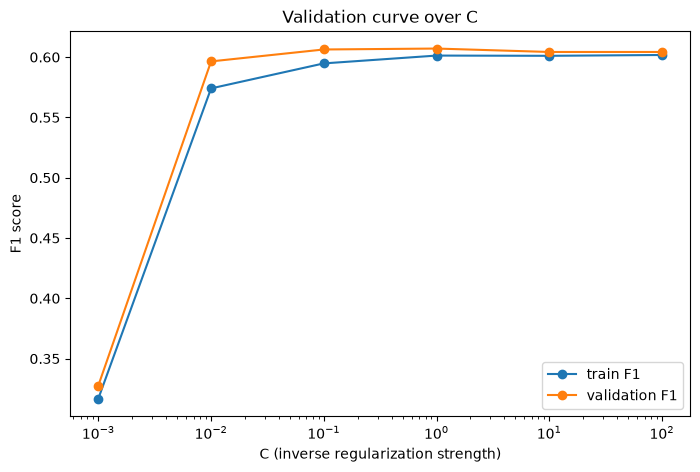

In [7]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_f1s, val_f1s = [], []
print(f"{'C':>7} {'train F1':>9} {'val F1':>7}")
for C in C_values:
    pipe = make_churn_pipeline(num_cols, cat_cols, C=C).fit(X_train, y_train)
    tr = f1_score(y_train, pipe.predict(X_train))
    va = f1_score(y_val, pipe.predict(X_val))
    train_f1s.append(tr)
    val_f1s.append(va)
    print(f"{C:>7} {tr:>9.3f} {va:>7.3f}")

plt.figure(figsize=(8, 5))
# semilogx: log-scaled x-axis, so each factor of 10 in C is one equal step
plt.semilogx(C_values, train_f1s, 'o-', label='train F1')
plt.semilogx(C_values, val_f1s, 'o-', label='validation F1')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('F1 score')
plt.title('Validation curve over C')
plt.legend()
plt.show()

> **Note:** The left edge shows what too much regularization does: at C=0.001 the model is constrained so hard that F1 drops to 0.33, worse than the numeric-only pipeline. From C=0.1 upward the curve is a flat plateau around 0.60, and the train and validation scores sit nearly on top of each other the whole way. No gap means there is no overfitting for regularization to fix, which should not surprise you: 4,225 training rows for 45 features is a comfortable ratio. The default C=1.0 sits on the plateau, and we keep it. On a dataset with more features or fewer rows, this same sweep is how you would find the setting that matters.

---
## Step 6: Final Model and Test Evaluation

Every decision is now made: features, preprocessing, C. So we retrain on everything except the test set (train plus validation, so the final model learns from the most data available), and use the test set for the one thing it exists for: a single honest measurement.

In [8]:
final_pipe = make_churn_pipeline(num_cols, cat_cols, C=0.001).fit(X_trainval, y_trainval)

test_metrics = evaluate(final_pipe, X_test, y_test)
print("Test-set performance:")
for name, value in test_metrics.items():
    print(f"  {name:<10} {value:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_pipe.predict(X_test)))

Test-set performance:
  accuracy   0.779
  precision  0.740
  recall     0.259
  f1         0.384

Confusion matrix:
[[1001   34]
 [ 277   97]]


> **Note:** Test F1 lands at 0.588, close to the validation plateau, so our choices did not secretly overfit the validation set. The confusion matrix breaks the errors down: 170 churners the model missed (false negatives) and 116 loyal customers it falsely flagged (false positives). The metrics say how often the model is wrong. They say nothing about *who* it gets wrong, and that is the question that actually drives the next improvement.

---
## Step 7: Error Analysis: Read Your Worst Mistakes

This step is where pipelines pay off again. `X_test` was never converted into an anonymous numeric matrix; it is still a readable DataFrame of customers. So attaching predicted probabilities to real rows is one line, and the model's most confident mistakes become rows you can read as real customers.

The worst false negatives are customers who churned while the model was most sure they would stay. The worst false positives are customers who stayed while the model was most sure they would churn.

In [9]:
results = X_test.copy()
results['actual_churn'] = y_test.values
results['p_churn'] = final_pipe.predict_proba(X_test)[:, 1]

show_cols = ['Contract', 'tenure', 'InternetService', 'MonthlyCharges', 'PaymentMethod', 'p_churn']

worst_fn = results[results['actual_churn'] == 1].sort_values('p_churn').head(10)
worst_fp = results[results['actual_churn'] == 0].sort_values('p_churn', ascending=False).head(10)

print("Worst false negatives (churned, model was sure they would stay):")
print(worst_fn[show_cols].to_string())
print(f"\nWorst false positives (stayed, model was sure they would churn):")
print(worst_fp[show_cols].to_string())
print(f"\nFor context, test-set averages: tenure {results['tenure'].mean():.1f} months, "
      f"monthly charges {results['MonthlyCharges'].mean():.2f}")

Worst false negatives (churned, model was sure they would stay):
      Contract  tenure InternetService  MonthlyCharges              PaymentMethod   p_churn
4819  Two year      53              No           19.75  Bank transfer (automatic)  0.068578
5579  Two year      70     Fiber optic           93.90  Bank transfer (automatic)  0.079851
4272  Two year      56              No           25.15    Credit card (automatic)  0.082488
3779  Two year      66             DSL           79.40    Credit card (automatic)  0.088962
4418  One year      58             DSL           60.30    Credit card (automatic)  0.098492
6289  Two year      67     Fiber optic          116.20    Credit card (automatic)  0.105842
842   One year      12              No           19.80  Bank transfer (automatic)  0.110898
2536  One year      25              No           25.30  Bank transfer (automatic)  0.117339
5086  One year      45              No           20.40           Electronic check  0.118815
6757  One year 

> **Note:** The patterns are easy to see. Every one of the ten worst false negatives is on a one- or two-year contract, most with tenure far above the 33-month average, several on automatic payments: the model has learned that contract plus tenure means safe, and assigns these customers almost no chance of leaving. The worst false positives are one repeated profile: month-to-month, fiber optic, electronic check, short tenure. That profile is so typical of churners that the model was confident they would leave.
>
> Both patterns say the same thing: the model leans very hard on a few columns. That observation is not a verdict; it is a hypothesis generator. Would an interaction feature help separate loyal fiber customers from leaving ones? Is there information the current columns simply do not carry? This loop, metrics then worst cases then hypothesis, is the improvement cycle for all your project work from here on.

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>Exercise: One hypothesis, one iteration</b>

Run one iteration the way you would on a real project:

1. Pick a single change to the full pipeline. Ideas: remove a feature group you believe matters (for example <code>Contract</code>), change the imputation strategy, or move C off the plateau.

2. <b>Before running it</b>, write one sentence predicting the effect on the validation metrics, and why.

3. Build the variant with <code>make_churn_pipeline</code> (adjust its arguments or edit a copy), fit on the training set, and compare all four validation metrics against the full pipeline.

4. Two or three sentences: what happened, and how did it compare to your prediction?

</div>

In [ ]:
# YOUR TURN
# 1. My change: My change: SimpleImputer strategy='mean'
# 2. My prediction (before running!): 
#    All metrics should decrease, because restricts the weights too much so the model is not able to fit the data as well
# 3. Build, fit, compare:
#    variant = make_churn_pipeline(num_cols, [c for c in cat_cols if c != 'Contract'])
#    variant.fit(X_train, y_train)
#    print(evaluate(variant, X_val, y_val))
#    print(evaluate(full_pipe, X_val, y_val))
# 4. What happened vs. what I predicted:
#    Validation F1 dropped from 0.607 to about 0.33, as predicted: C=0.001
#    underfits the model. there was no overfitting to fix, so leaving the plateau made the model worse.

<details><summary><b>Click for Solution</b></summary>

There is no single right answer; what matters is comparing your prediction with the actual outcome. Two worked examples:

**Dropping `Contract`.** Given the error analysis, you would predict a large drop: the model leans on contract type more than on anything else. The actual result: validation F1 slips from 0.607 to about 0.597, a real but surprisingly small drop. The reason is correlation: much of what `Contract` says is also said by `tenure` and `TotalCharges` (long contracts and long tenures travel together), so the remaining columns absorb most of the signal. A useful general lesson: with correlated features, removing one column rarely costs as much as its apparent importance suggests.

**Switching the imputer to `strategy='mean'`.** Prediction: no visible change, because only 6 of 4,225 training rows have a missing `TotalCharges` at all, and the lever is too small to move anything. Actual result: F1 about 0.606 versus 0.607. Confirmed. A change with no mechanism to matter did not matter, and verifying that is not wasted work; it is one more thing you now know instead of assume.

</details>

---
## What You Should Be Able to Do Now

- Build a classification pipeline whose numeric branch imputes and scales, and whose categorical branch one-hot encodes, in one object.
- Explain why imputation belongs inside the pipeline rather than in a `dropna` before it.
- Run a three-way split and say what each of the three sets is for.
- Tune `C` with a validation sweep and read a flat curve as "nothing here to fix."
- Deliver a final test verdict from a model retrained on all non-test data.
- Join predicted probabilities back to raw rows and mine the worst false negatives and false positives for your next hypothesis.